4.98851185540785


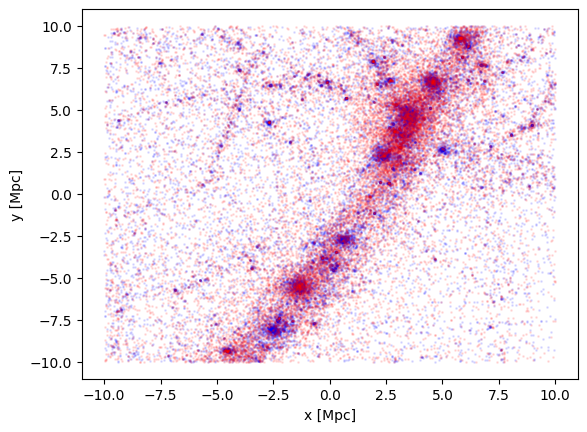

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
f=h5py.File("/Users/24756376/data/Flamingo/L0200N0360/LSS_coord.hdf5",'r')
dm=np.array(f["PartType1"]["Coordinates"])
g=np.array(f["PartType0"]["Coordinates"])
f.close()
crop_dm=(dm[:,0]>75)*(dm[:,0]<95)*(dm[:,1]>55)*(dm[:,1]<75)
crop_g=(g[:,0]>75)*(g[:,0]<95)*(g[:,1]>55)*(g[:,1]<75)
dm=dm[crop_dm]
g=g[crop_g]
dm[:,0]-=85
dm[:,1]-=65
g[:,0]-=85
g[:,1]-=65
dm[:,2]-=5
g[:,2]-=5
print(np.max(dm[:,2]))
#i=plt.imshow(fbar,cmap='bwr',vmin=-0.2,vmax=0.2,extent=[0,50,0,50])
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
ax.scatter(dm[:,0],dm[:,1],s=1,c='blue',alpha=0.1)
ax.scatter(g[:,0],g[:,1],s=1,c='red',alpha=0.1)
#plt.colorbar(i,label="baryon relative excess")
plt.xlabel(r"x [Mpc]")
plt.ylabel(r"y [Mpc]")
f=h5py.File("/Users/24756376/data/Flamingo/L0200N0360/LSS_filament.hdf5",'w')
P_dm=f.create_group("PartType1")
P_g=f.create_group("PartType0")
P_dm.create_dataset("Coordinates",data=dm)
P_g.create_dataset("Coordinates",data=g)

f.close()

0.8645238627389229
(500, 500)


Text(0, 0.5, 'y [Mpc]')

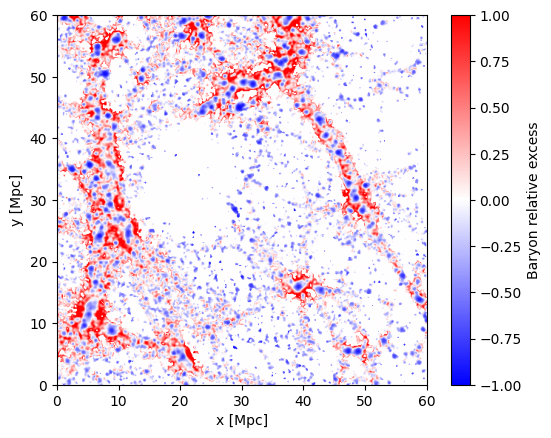

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
f=h5py.File("/Users/24756376//LSS_density.hdf5",'r')
g=np.array(f["g"])

dm=np.array(f["dm"])
#dm_res=np.array(f["dm_res"])
print(np.sum(g)/np.sum(dm))
fb=np.zeros((500,500))
f_res=np.zeros((500,500))
fb[dm>30]=(g*8.56/(g*8.56+dm*45.2)/0.168-1)[dm>30]
f_res[dm<100]=(g*8.56/(g*8.56+dm*45.2)/0.168-1)[dm<100]
f.close()
print(fb.shape)
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
p=plt.imshow(fb[0:500,0:500],vmin=-1,vmax=1,cmap='bwr',extent=[0,60,0,60])

#res=plt.imshow(f_res[0:700,0:700],vmin=-0.2,vmax=0.2,cmap='grey',extent=[0,50,0,50])
plt.colorbar(p,label="Baryon relative excess")
plt.xlabel(r"x [Mpc]")
plt.ylabel(r"y [Mpc]")

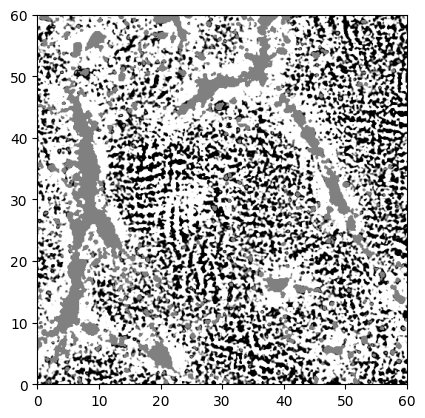

In [46]:
res=plt.imshow(f_res[0:700,0:700],vmin=-0.2,vmax=0.2,cmap='grey',extent=[0,60,0,60])

[-2.         -1.66666667 -1.33333333 -1.         -0.66666667 -0.33333333
  0.          0.33333333  0.66666667  1.        ]
[5.27244000e+05 2.56001800e+06 2.38304420e+07 2.13783044e+08
 1.58626296e+09 7.82093630e+09 2.23964199e+10 7.08507821e+10
 4.21749788e+11]


Text(0.5, 0, '$r[Mpc]$')

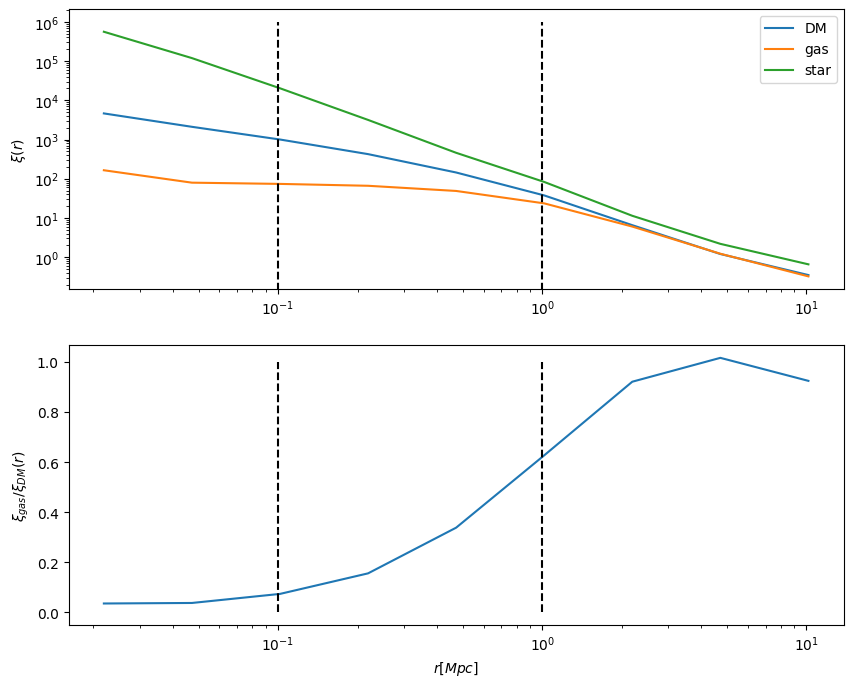

In [16]:
h=0.67
f=h5py.File("/Users/24756376/data/Flamingo/L1000N1800_NoCool/correlation_functions.hdf5",'r')
dm=np.array(f["dm"])
g=np.array(f['gas'])
s=np.array(f['star'])
bins=np.log10(np.array(f["rbins"]))
f.close()
print(bins)
bin=10**(0.5*(bins[1:]+bins[:-1]))
xi_dm=np.zeros(len(dm))
xi_g=np.zeros(len(g))
xi_s=np.zeros(len(s))
N_dm=np.zeros(len(dm))
N_g=np.zeros(len(g))
N_s=np.zeros(len(s))
for i in range(len(dm)):
    xi_dm[i]=dm[i][3]
    xi_g[i]=g[i][3]
    xi_s[i]=s[i][3]
    N_dm[i]=dm[i][4]
    N_g[i]=g[i][4]
    N_s[i]=s[i][4]
fig=plt.figure(figsize=(10, 8))
print(N_g)
ax=fig.add_subplot(2,1,1,)
ax.plot(bin/h,xi_dm,label='DM')
ax.plot(bin/h,xi_g,label='gas')
ax.plot(bin/h,xi_s,label='star')
ax.vlines(x=0.1,ymin=0,ymax=10**6,linestyle='dashed',color='black')
ax.vlines(x=1,ymin=0,ymax=10**6,linestyle='dashed',color='black')
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel(r'$\xi (r)$')
ax.legend()
ax=fig.add_subplot(2,1,2)
ax.plot(bin/h,xi_g/xi_dm,label=r'DM/g')
ax.vlines(x=0.1,ymin=0,ymax=1,linestyle='dashed',color='black')
ax.vlines(x=1,ymin=0,ymax=1,linestyle='dashed',color='black')
ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_ylabel(r'$\xi_{gas}/\xi_{DM} (r)$')
ax.set_xlabel(r'$r[Mpc]$')
